In [1]:
# Check GPU
!nvidia-smi

Fri Jul 10 10:09:09 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.159.04             Driver Version: 580.159.04     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   38C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0"

In [3]:
!pip install -q -U transformers accelerate peft trl datasets bitsandbytes

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.5/11.5 MB 99.7 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 389.2/389.2 kB 29.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 863.2/863.2 kB 49.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 33.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 516.0/516.0 kB 37.7 MB/s eta 0:00:00


In [4]:
import transformers, peft, trl, torch
print("transformers:", transformers.__version__)
print("peft:", peft.__version__)
print("trl:", trl.__version__)
print("torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

transformers: 5.13.0
peft: 0.19.1
trl: 1.8.0
torch: 2.10.0+cu128
CUDA available: True


In [5]:
import os

# List the dataset folder to find the exact file
for root, dirs, files in os.walk('/kaggle/input'):
    for f in files:
        print(os.path.join(root, f))

/kaggle/input/datasets/thedevastator/alpaca-language-instruction-training/train.csv


In [6]:
import pandas as pd

df = pd.read_csv('/kaggle/input/datasets/thedevastator/alpaca-language-instruction-training/train.csv')

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
df.head(3)

Shape: (51760, 3)

Columns: ['instruction', 'output', 'input']


,instruction,output,input
0,Give three tips for staying healthy.,1. Eat a balanced and nutritious diet: Make su...,NaN
1,What are the three primary colors?,"The three primary colors are red, blue, and ye...",NaN
2,Describe the structure of an atom.,An atom is the basic building block of all mat...,NaN


In [7]:
import numpy as np

# Same seed as your LoRA run — keeps the comparison fair
df_sample = df.sample(n=2000, random_state=42).reset_index(drop=True)
df_sample['input'] = df_sample['input'].fillna('')

print("Sampled shape:", df_sample.shape)
print("\nHow many have non-empty input:", (df_sample['input'] != '').sum())

Sampled shape: (2000, 3)

How many have non-empty input: 713


In [8]:
from transformers import AutoTokenizer

model_name = "Qwen/Qwen2.5-1.5B-Instruct"
tokenizer = AutoTokenizer.from_pretrained(model_name)

def format_example(row):
    if row['input'].strip() != '':
        user_content = f"{row['instruction']}\n\n{row['input']}"
    else:
        user_content = row['instruction']

    messages = [
        {"role": "user", "content": user_content},
        {"role": "assistant", "content": row['output']}
    ]

    text = tokenizer.apply_chat_template(messages, tokenize=False)
    return text

# Test on one example
sample_formatted = format_example(df_sample.iloc[0])
print(sample_formatted)

config.json:   0%|          | 0.00/660 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

<|im_start|>system
You are Qwen, created by Alibaba Cloud. You are a helpful assistant.<|im_end|>
<|im_start|>user
How can you use technology to improve your customer service?<|im_end|>
<|im_start|>assistant
There are several ways technology can be used to improve customer service, including the following:

1. Implementing Chatbots: Chatbots can help provide a faster, more personalized service to your customers. Equipped with artificial intelligence and natural language processing algorithms, chatbots can quickly respond to customer queries, saving customers time and providing them with immediate assistance.

2. Using Social Media: Using social media platforms to interact with customers is an excellent way to improve customer service. By maintaining an active presence on social media, companies can respond to messages and comments promptly, providing customers with an additional, convenient way to reach out for support.

3. Creating a customer-centered website: The company's website sh

In [9]:
from datasets import Dataset

df_sample['text'] = df_sample.apply(format_example, axis=1)

text_lengths = df_sample['text'].apply(lambda x: len(tokenizer(x)['input_ids']))
print("Token length stats:")
print(text_lengths.describe())
print("\n% of examples over 512 tokens:", (text_lengths > 512).mean() * 100)

train_dataset = Dataset.from_pandas(df_sample[['text']])
print("\nDataset ready:", train_dataset)

Token length stats:
count    2000.000000
mean      191.662000
std       129.324418
min        42.000000
25%        77.000000
50%       156.000000
75%       279.000000
max      1055.000000
Name: text, dtype: float64

% of examples over 512 tokens: 1.7999999999999998

Dataset ready: Dataset({
    features: ['text'],
    num_rows: 2000
})


In [10]:
import torch
from transformers import AutoModelForCausalLM, BitsAndBytesConfig

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",              # NormalFloat4 — matches weight distribution better than plain int4
    bnb_4bit_compute_dtype=torch.float16,  # actual matmuls happen in bf16, weights dequantized on-the-fly
    bnb_4bit_use_double_quant=True,         # quantize the quantization constants too — extra ~0.4 bits/param saved
)

model = AutoModelForCausalLM.from_pretrained(
    model_name,
    quantization_config=bnb_config,
    dtype=torch.float16, 
    device_map="cuda:0",
)

print(model)

model.safetensors:   0%|          | 0.00/3.09G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/242 [00:00<?, ?B/s]

Qwen2ForCausalLM(
  (model): Qwen2Model(
    (embed_tokens): Embedding(151936, 1536)
    (layers): ModuleList(
      (0-27): 28 x Qwen2DecoderLayer(
        (self_attn): Qwen2Attention(
          (q_proj): Linear4bit(in_features=1536, out_features=1536, bias=True)
          (k_proj): Linear4bit(in_features=1536, out_features=256, bias=True)
          (v_proj): Linear4bit(in_features=1536, out_features=256, bias=True)
          (o_proj): Linear4bit(in_features=1536, out_features=1536, bias=False)
        )
        (mlp): Qwen2MLP(
          (gate_proj): Linear4bit(in_features=1536, out_features=8960, bias=False)
          (up_proj): Linear4bit(in_features=1536, out_features=8960, bias=False)
          (down_proj): Linear4bit(in_features=8960, out_features=1536, bias=False)
          (act_fn): SiLUActivation()
        )
        (input_layernorm): Qwen2RMSNorm((1536,), eps=1e-06)
        (post_attention_layernorm): Qwen2RMSNorm((1536,), eps=1e-06)
      )
    )
    (norm): Qwen2RMSNorm((1

In [11]:
print(f"GPU memory allocated: {torch.cuda.memory_allocated() / 1024**3:.2f} GB")
print(f"GPU memory reserved: {torch.cuda.memory_reserved() / 1024**3:.2f} GB")

GPU memory allocated: 1.07 GB
GPU memory reserved: 1.12 GB


In [12]:
from peft import prepare_model_for_kbit_training

model = prepare_model_for_kbit_training(model)

In [13]:
from peft import LoraConfig, get_peft_model

lora_config = LoraConfig(
    r=16,                   
    lora_alpha=32,           
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj"],
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM"
)

peft_model = get_peft_model(model, lora_config)
peft_model.print_trainable_parameters()

trainable params: 4,358,144 || all params: 1,548,072,448 || trainable%: 0.2815


In [14]:
from trl import SFTConfig, SFTTrainer

training_args = SFTConfig(
    output_dir="/kaggle/working/qwen_qlora_checkpoints",
    per_device_train_batch_size=4,
    gradient_accumulation_steps=4,
    num_train_epochs=2,
    learning_rate=2e-4,
    logging_steps=10,
    save_strategy="epoch",
    max_length=512,
    dataset_text_field="text",
    report_to="none",
    fp16=False,             # switched back — matches T4 hardware
    bf16=False,
    optim="paged_adamw_8bit",
)

trainer = SFTTrainer(
    model=peft_model,
    args=training_args,
    train_dataset=train_dataset,
)

print("Trainer ready. Total training steps:", len(trainer.get_train_dataloader()) * training_args.num_train_epochs)

Adding EOS to train dataset:   0%|          | 0/2000 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/2000 [00:00<?, ? examples/s]

Building labels for train dataset:   0%|          | 0/2000 [00:00<?, ? examples/s]

Truncating train dataset:   0%|          | 0/2000 [00:00<?, ? examples/s]

Trainer ready. Total training steps: 1000


In [15]:
import time

start_time = time.time()
train_result = trainer.train()
end_time = time.time()

training_duration = end_time - start_time
print(f"\nTraining completed in {training_duration/60:.2f} minutes")
print(f"Final training loss: {train_result.training_loss:.4f}")

[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None, 'pad_token_id': 151643}.


Step,Training Loss
10,1.597657
20,1.216256
30,1.126151
40,1.067502
50,1.068562
60,1.096130
70,1.072762
80,1.106025
90,1.029711
100,1.064878



Training completed in 26.69 minutes
Final training loss: 1.0851


In [16]:
print(f"Peak GPU memory allocated: {torch.cuda.max_memory_allocated() / 1024**3:.2f} GB")
print(f"Peak GPU memory reserved: {torch.cuda.max_memory_reserved() / 1024**3:.2f} GB")

Peak GPU memory allocated: 2.50 GB
Peak GPU memory reserved: 2.61 GB


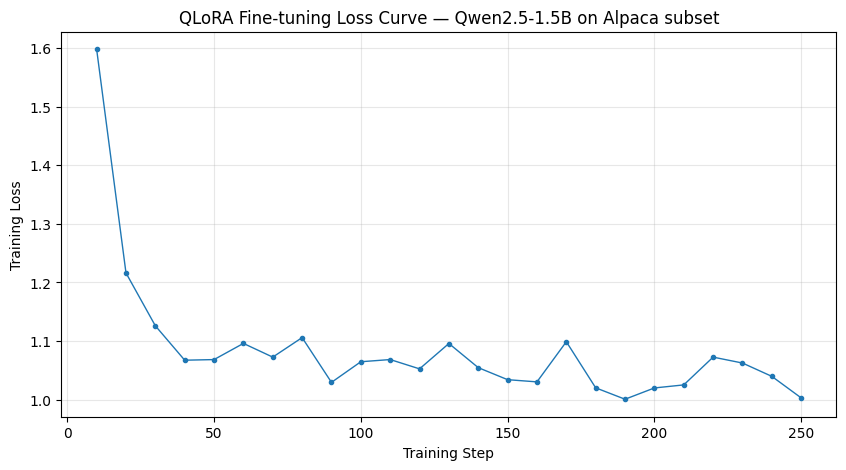

Loss curve saved. Min loss: 1.0010, Max loss: 1.5977


In [17]:
import matplotlib.pyplot as plt

log_history = trainer.state.log_history
steps = [entry['step'] for entry in log_history if 'loss' in entry]
losses = [entry['loss'] for entry in log_history if 'loss' in entry]

plt.figure(figsize=(10, 5))
plt.plot(steps, losses, marker='o', markersize=3, linewidth=1)
plt.xlabel('Training Step')
plt.ylabel('Training Loss')
plt.title('QLoRA Fine-tuning Loss Curve — Qwen2.5-1.5B on Alpaca subset')
plt.grid(True, alpha=0.3)
plt.savefig('/kaggle/working/qlora_training_loss_curve.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Loss curve saved. Min loss: {min(losses):.4f}, Max loss: {max(losses):.4f}")

In [18]:
adapter_path = "/kaggle/working/qwen_qlora_adapter"
peft_model.save_pretrained(adapter_path)
tokenizer.save_pretrained(adapter_path)

import os
total_size = 0
for dirpath, dirnames, filenames in os.walk(adapter_path):
    for f in filenames:
        fp = os.path.join(dirpath, f)
        total_size += os.path.getsize(fp)

print(f"Adapter saved to: {adapter_path}")
print(f"Adapter size: {total_size / (1024*1024):.2f} MB")

for f in os.listdir(adapter_path):
    print(" -", f)

Adapter saved to: /kaggle/working/qwen_qlora_adapter
Adapter size: 19.24 MB
 - README.md
 - adapter_model.safetensors
 - adapter_config.json
 - tokenizer.json
 - chat_template.jinja
 - tokenizer_config.json


In [19]:
import gc

del trainer
gc.collect()
torch.cuda.empty_cache()

print(f"GPU memory after cleanup: {torch.cuda.memory_allocated() / 1024**3:.2f} GB")

GPU memory after cleanup: 1.54 GB


In [21]:
!pip uninstall -y torchao

Found existing installation: torchao 0.10.0
Uninstalling torchao-0.10.0:
  Successfully uninstalled torchao-0.10.0


In [22]:
from peft import PeftModel

# Load a CLEAN, non-quantized copy of the base model — this is the "dequantize" step conceptually.
# Note: we're not converting the 4-bit weights back to fp16 — we're loading the ORIGINAL fp16 weights
# fresh from the hub. Merging requires full-precision weights to add the LoRA delta accurately.
base_model_for_merge = AutoModelForCausalLM.from_pretrained(
    model_name,
    dtype=torch.float16,
    device_map="cuda:0",
)

# Attach the trained adapter on top of this full-precision base
merged_model = PeftModel.from_pretrained(base_model_for_merge, adapter_path)

# Merge LoRA weights into the base model permanently: W_new = W_base + (B @ A) * (alpha/r)
merged_model = merged_model.merge_and_unload()

print("Merge complete.")
print(type(merged_model))

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

Merge complete.
<class 'transformers.models.qwen2.modeling_qwen2.Qwen2ForCausalLM'>


In [23]:
merged_model_path = "/kaggle/working/qwen_qlora_merged_model"

merged_model.save_pretrained(merged_model_path)
tokenizer.save_pretrained(merged_model_path)

import os
total_size = 0
for dirpath, dirnames, filenames in os.walk(merged_model_path):
    for f in filenames:
        fp = os.path.join(dirpath, f)
        total_size += os.path.getsize(fp)

print(f"Merged model saved to: {merged_model_path}")
print(f"Merged model size: {total_size / (1024*1024):.2f} MB")

for f in os.listdir(merged_model_path):
    print(" -", f)

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Merged model saved to: /kaggle/working/qwen_qlora_merged_model
Merged model size: 2955.34 MB
 - model.safetensors
 - tokenizer.json
 - generation_config.json
 - chat_template.jinja
 - config.json
 - tokenizer_config.json


In [29]:
del base_model_for_merge, merged_model
gc.collect()
torch.cuda.empty_cache()
print("GPU memory freed.")

GPU memory freed.


In [30]:
!free -h

               total        used        free      shared  buff/cache   available
Mem:            31Gi        19Gi       275Mi        15Mi        11Gi        11Gi
Swap:             0B          0B          0B


In [31]:
from transformers import AutoModelForCausalLM, AutoTokenizer
import torch, time

# Fine-tuned (QLoRA-merged) model
cpu_model_path = "/kaggle/working/qwen_qlora_merged_model"
tokenizer_cpu = AutoTokenizer.from_pretrained(cpu_model_path)
cpu_model = AutoModelForCausalLM.from_pretrained(
    cpu_model_path,
    dtype=torch.float32,   # CPU inference typically uses fp32
    device_map="cpu"
)
print("Fine-tuned model loaded on:", cpu_model.device)

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

Fine-tuned model loaded on: cpu


In [32]:
# Base (untouched) model for comparison
base_model_path = "Qwen/Qwen2.5-1.5B-Instruct"
tokenizer_base = AutoTokenizer.from_pretrained(base_model_path)
base_model_cpu = AutoModelForCausalLM.from_pretrained(
    base_model_path,
    dtype=torch.float32,
    device_map="cpu"
)
print("Base model loaded on:", base_model_cpu.device)

Loading weights:   0%|          | 0/338 [00:00<?, ?it/s]

Base model loaded on: cpu


In [33]:
def generate_response(model, tokenizer, user_prompt, max_new_tokens=150):
    messages = [{"role": "user", "content": user_prompt}]
    text = tokenizer.apply_chat_template(messages, tokenize=False, add_generation_prompt=True)
    inputs = tokenizer(text, return_tensors="pt")

    start = time.time()
    with torch.no_grad():
        output = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=False,
            temperature=None,
            top_p=None,
            pad_token_id=tokenizer.eos_token_id
        )
    end = time.time()

    generated_tokens = output[0][inputs['input_ids'].shape[1]:]
    response = tokenizer.decode(generated_tokens, skip_special_tokens=True)
    duration = end - start
    num_tokens = len(generated_tokens)
    tokens_per_sec = num_tokens / duration if duration > 0 else 0

    return response, duration, num_tokens, tokens_per_sec

In [34]:
test_prompts = [
    "Give three tips for staying healthy.",
    "What are the three primary colors?",
    "Write a short poem about the ocean.",
    "Explain what machine learning is in simple terms.",
    "List two benefits of regular exercise."
]

results = []

for prompt in test_prompts:
    print(f"\n{'='*80}\nPROMPT: {prompt}\n{'='*80}")

    base_response, base_time, base_tokens, base_tps = generate_response(base_model_cpu, tokenizer_base, prompt)
    print(f"\n--- BASE MODEL (before fine-tuning) ---")
    print(base_response)
    print(f"[Time: {base_time:.2f}s | Tokens: {base_tokens} | Speed: {base_tps:.2f} tok/s]")

    ft_response, ft_time, ft_tokens, ft_tps = generate_response(cpu_model, tokenizer_cpu, prompt)
    print(f"\n--- FINE-TUNED MODEL (after QLoRA) ---")
    print(ft_response)
    print(f"[Time: {ft_time:.2f}s | Tokens: {ft_tokens} | Speed: {ft_tps:.2f} tok/s]")

    results.append({
        'prompt': prompt,
        'base_response': base_response, 'base_time': base_time, 'base_tps': base_tps,
        'ft_response': ft_response, 'ft_time': ft_time, 'ft_tps': ft_tps
    })


PROMPT: Give three tips for staying healthy.

--- BASE MODEL (before fine-tuning) ---
1. Eat a balanced diet: Eating a variety of fruits, vegetables, whole grains, and lean proteins can help you maintain good health.
2. Exercise regularly: Regular physical activity can improve your overall health and well-being, including reducing the risk of chronic diseases such as heart disease, diabetes, and obesity.
3. Get enough sleep: Getting adequate sleep is important for maintaining good health, including regulating hormones that affect appetite, mood, and energy levels. Aim for 7-9 hours of quality sleep per night.
[Time: 30.75s | Tokens: 105 | Speed: 3.41 tok/s]

--- FINE-TUNED MODEL (after QLoRA) ---
1. Eat a balanced diet: A healthy diet is essential to maintaining good health and preventing diseases. Eating plenty of fruits, vegetables, whole grains, lean proteins, and healthy fats can help you stay energized and reduce your risk of chronic conditions such as heart disease, diabetes, an

In [35]:
train_indices = set(df_sample.index) if 'train_indices' not in dir() else train_indices

In [36]:
import pandas as pd

df = pd.read_csv('/kaggle/input/datasets/thedevastator/alpaca-language-instruction-training/train.csv')

# Reconstruct the exact same training sample to identify which original indices were used
df_sample_check = df.sample(n=2000, random_state=42)
train_indices = set(df_sample_check.index)

# Now pick held-out samples from what's NOT in training
remaining_df = df[~df.index.isin(train_indices)]
held_out_df = remaining_df.sample(n=100, random_state=123)

overlap = set(held_out_df.index) & train_indices
print("True overlap (should be 0):", len(overlap))

held_out_df = held_out_df.reset_index(drop=True)
held_out_df['input'] = held_out_df['input'].fillna('')

print("Held-out set size:", held_out_df.shape)

True overlap (should be 0): 0
Held-out set size: (100, 3)


In [37]:
import math

def compute_perplexity(model, tokenizer, df, max_length=512):
    total_loss = 0.0
    total_tokens = 0

    model.eval()
    with torch.no_grad():
        for idx, row in df.iterrows():
            if row['input'].strip() != '':
                user_content = f"{row['instruction']}\n\n{row['input']}"
            else:
                user_content = row['instruction']

            messages = [
                {"role": "user", "content": user_content},
                {"role": "assistant", "content": row['output']}
            ]
            text = tokenizer.apply_chat_template(messages, tokenize=False)

            inputs = tokenizer(text, return_tensors="pt", truncation=True, max_length=max_length)
            input_ids = inputs['input_ids']

            outputs = model(input_ids, labels=input_ids)

            num_tokens = input_ids.shape[1]
            total_loss += outputs.loss.item() * num_tokens
            total_tokens += num_tokens

    avg_loss = total_loss / total_tokens
    perplexity = math.exp(avg_loss)
    return perplexity, avg_loss

print("Computing perplexity for BASE model...")
base_ppl, base_avg_loss = compute_perplexity(base_model_cpu, tokenizer_base, held_out_df)
print(f"Base model perplexity: {base_ppl:.4f} (avg loss: {base_avg_loss:.4f})")

print("\nComputing perplexity for QLoRA FINE-TUNED model...")
ft_ppl, ft_avg_loss = compute_perplexity(cpu_model, tokenizer_cpu, held_out_df)
print(f"QLoRA fine-tuned model perplexity: {ft_ppl:.4f} (avg loss: {ft_avg_loss:.4f})")

print(f"\nPerplexity improvement: {((base_ppl - ft_ppl) / base_ppl * 100):.2f}%")

Computing perplexity for BASE model...
Base model perplexity: 6.5650 (avg loss: 1.8818)

Computing perplexity for QLoRA FINE-TUNED model...
QLoRA fine-tuned model perplexity: 2.8269 (avg loss: 1.0392)

Perplexity improvement: 56.94%


In [ ]:
import shutil

shutil.make_archive('/kaggle/working/qwen_qlora_merged_model', 'zip', '/kaggle/working/qwen_qlora_merged_model')
shutil.make_archive('/kaggle/working/qwen_qlora_adapter', 'zip', '/kaggle/working/qwen_qlora_adapter')

for f in os.listdir('/kaggle/working'):
    if f.endswith('.zip'):
        size_mb = os.path.getsize(f'/kaggle/working/{f}') / (1024*1024)
        print(f"{f}: {size_mb:.2f} MB")